170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1580s 9us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


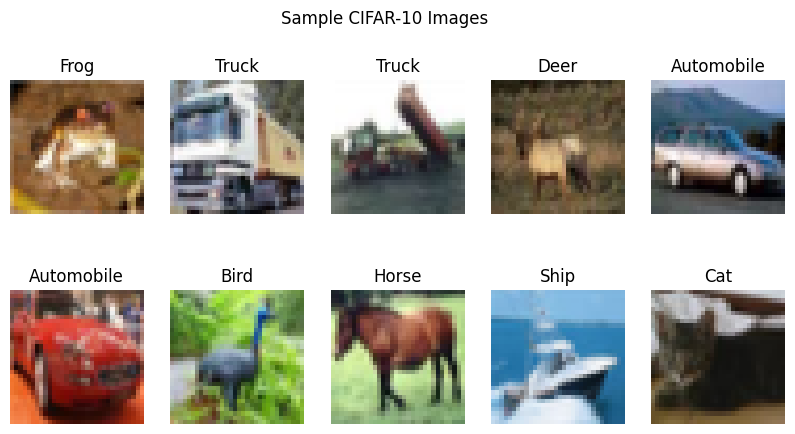

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

class_names = ['Airplane','Automobile','Bird','Cat','Deer',
               'Dog','Frog','Horse','Ship','Truck']

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

# Normalize to [0,1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Display 10 sample images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("Sample CIFAR-10 Images")
plt.show()

In [ ]:
IMG_SIZE = 96  # large enough for VGG16/ResNet50/InceptionV3 minimum input requirements

def make_resized_dataset(images, labels, batch_size=32, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        ds = ds.shuffle(2000)
    ds = ds.map(lambda img, lbl: (tf.image.resize(img, (IMG_SIZE, IMG_SIZE)), lbl),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_resized_dataset(x_train_norm, y_train_cat, batch_size=32, shuffle=True)
test_ds = make_resized_dataset(x_test_norm, y_test_cat, batch_size=32, shuffle=False)

In [ ]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # freeze convolutional base

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_fe = model.fit(train_ds, validation_data=test_ds, epochs=10, verbose=1)
fe_time = time.time() - start_time

print(f"\nFeature extraction training time: {fe_time:.1f}s")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 51ms/step - accuracy: 0.5884 - loss: 1.2061 - val_accuracy: 0.6447 - val_loss: 1.0247
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.6646 - loss: 0.9664 - val_accuracy: 0.6626 - val_loss: 0.9671
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.6833 - loss: 0.9095 - val_accuracy: 0.6685 - val_loss: 0.9486
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.6952 - loss: 0.8742 - val_accuracy: 0.6844 - val_loss: 0.9039
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.7057 - loss: 0.8463 - val_accuracy: 0.6904 - val_loss: 0.8826
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.7125 - loss: 0.8259 - val_accuracy: 0.6943 - val_loss: 0.8758
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.7204 - loss: 0.8046 - val_accuracy: 0.6902 - val_loss: 0.8833
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.7262 -

In [ ]:
# Unfreeze the last convolutional block of VGG16
base_model.trainable = True
for layer in base_model.layers[:-4]:   # keep all but the last block frozen
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much smaller LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_ft = model.fit(train_ds, validation_data=test_ds, epochs=8, verbose=1)
ft_time = time.time() - start_time

print(f"\nFine-tuning training time: {ft_time:.1f}s")

# Compare accuracy before vs after fine-tuning
print(f"Best val accuracy BEFORE fine-tuning: {max(history_fe.history['val_accuracy']):.4f}")
print(f"Best val accuracy AFTER fine-tuning:  {max(history_ft.history['val_accuracy']):.4f}")

Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 114s 70ms/step - accuracy: 0.7817 - loss: 0.6257 - val_accuracy: 0.7723 - val_loss: 0.6616
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.8492 - loss: 0.4284 - val_accuracy: 0.8026 - val_loss: 0.5940
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.8925 - loss: 0.3137 - val_accuracy: 0.8143 - val_loss: 0.5629
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.9249 - loss: 0.2258 - val_accuracy: 0.8190 - val_loss: 0.5710
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.9497 - loss: 0.1609 - val_accuracy: 0.8250 - val_loss: 0.5916
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.9680 - loss: 0.1108 - val_accuracy: 0.8317 - val_loss: 0.6000
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.9790 - loss: 0.0772 - val_accuracy: 0.8346 - val_loss: 0.6116
Epoch 8/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 106s 68ms/step - accuracy: 0.9870 -

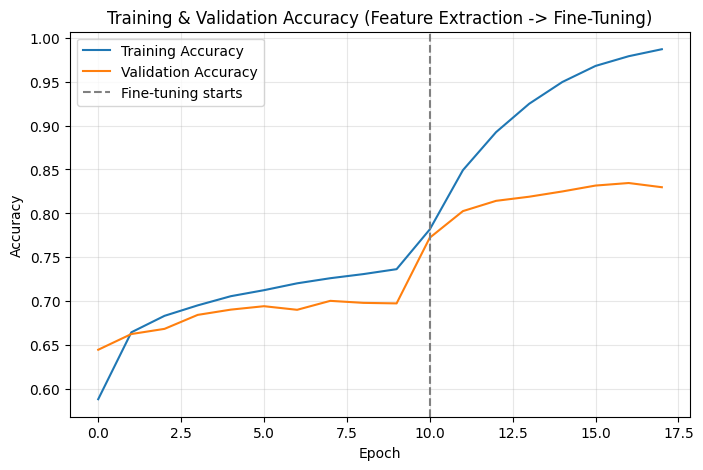

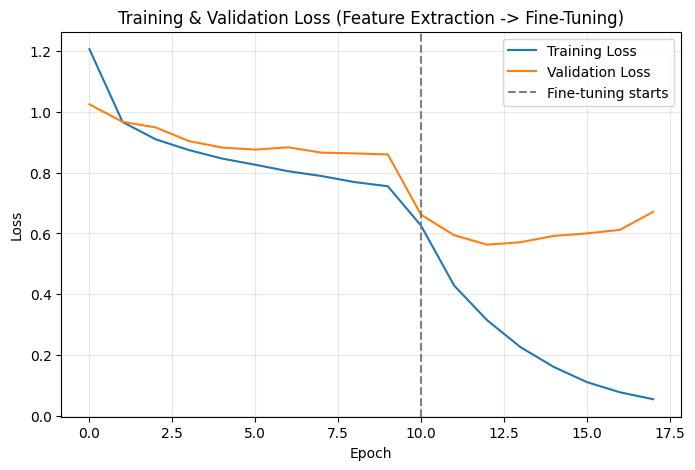

In [ ]:
# Combine both training phases into one continuous history for plotting
full_acc = history_fe.history['accuracy'] + history_ft.history['accuracy']
full_val_acc = history_fe.history['val_accuracy'] + history_ft.history['val_accuracy']
full_loss = history_fe.history['loss'] + history_ft.history['loss']
full_val_loss = history_fe.history['val_loss'] + history_ft.history['val_loss']

fine_tune_start = len(history_fe.history['accuracy'])

plt.figure(figsize=(8,5))
plt.plot(full_acc, label='Training Accuracy')
plt.plot(full_val_acc, label='Validation Accuracy')
plt.axvline(fine_tune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy (Feature Extraction -> Fine-Tuning)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(8,5))
plt.plot(full_loss, label='Training Loss')
plt.plot(full_val_loss, label='Validation Loss')
plt.axvline(fine_tune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training & Validation Loss (Feature Extraction -> Fine-Tuning)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step
Test Accuracy : 0.8298
Precision     : 0.8348
Recall        : 0.8298
F1-score      : 0.8306
Total Parameters: 14,781,642

Classification Report:

              precision    recall  f1-score   support

    Airplane       0.86      0.89      0.87      1000
  Automobile       0.92      0.89      0.90      1000
        Bird       0.84      0.77      0.80      1000
         Cat       0.70      0.66      0.68      1000
        Deer       0.84      0.75      0.79      1000
         Dog       0.65      0.83      0.73      1000
        Frog       0.88      0.84      0.86      1000
       Horse       0.87      0.85      0.86      1000
        Ship       0.91      0.91      0.91      1000
       Truck       0.88      0.91      0.89      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



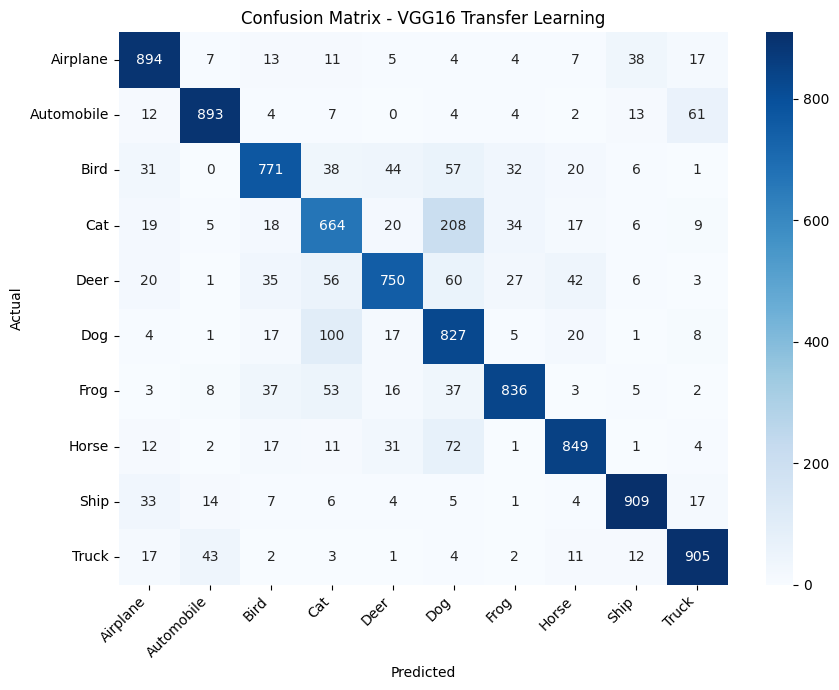

In [ ]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1-score      : {f1:.4f}")
print(f"Total Parameters: {model.count_params():,}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG16 Transfer Learning")
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

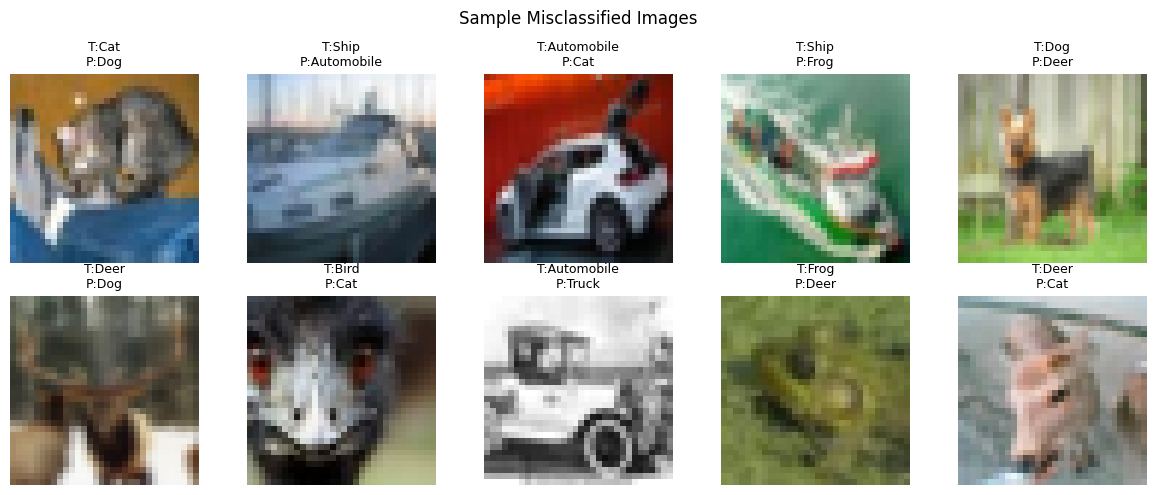

In [ ]:
misclassified_idx = np.where(y_pred != y_true)[0][:10]

plt.figure(figsize=(12,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Misclassified Images")
plt.tight_layout(); plt.show()

In [ ]:
def build_vgg16_model(dense_units=128, frozen='all'):
    base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    if frozen == 'all':
        base.trainable = False
    else:  # partial
        base.trainable = True
        for layer in base.layers[:-4]:
            layer.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs)

hp_configs = [
    {"lr": 0.001, "batch": 32, "optimizer": "adam", "dense_units": 128, "frozen": "all"},
    {"lr": 0.0001, "batch": 32, "optimizer": "adam", "dense_units": 128, "frozen": "all"},
    {"lr": 0.001, "batch": 32, "optimizer": "sgd", "dense_units": 128, "frozen": "all"},
    {"lr": 0.001, "batch": 32, "optimizer": "adam", "dense_units": 256, "frozen": "all"},
    {"lr": 0.001, "batch": 32, "optimizer": "adam", "dense_units": 128, "frozen": "partial"},
]

hp_results = []
EPOCHS_HP = 5

for cfg in hp_configs:
    print(f"\nConfig: {cfg}")
    m = build_vgg16_model(dense_units=cfg["dense_units"], frozen=cfg["frozen"])
    opt = tf.keras.optimizers.Adam(learning_rate=cfg["lr"]) if cfg["optimizer"]=="adam" \
          else tf.keras.optimizers.SGD(learning_rate=cfg["lr"], momentum=0.9)
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    train_ds_hp = make_resized_dataset(x_train_norm, y_train_cat, batch_size=cfg["batch"], shuffle=True)
    test_ds_hp = make_resized_dataset(x_test_norm, y_test_cat, batch_size=cfg["batch"])

    hist = m.fit(train_ds_hp, validation_data=test_ds_hp, epochs=EPOCHS_HP, verbose=0)
    best_val_acc = max(hist.history['val_accuracy'])
    hp_results.append({**cfg, "val_accuracy": best_val_acc})
    print(f"  -> Best val accuracy: {best_val_acc:.4f}")

print("\nHyperparameter Study Summary:")
for r in hp_results:
    print(r)


Config: {'lr': 0.001, 'batch': 32, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all'}
  -> Best val accuracy: 0.6841

Config: {'lr': 0.0001, 'batch': 32, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all'}
  -> Best val accuracy: 0.6409

Config: {'lr': 0.001, 'batch': 32, 'optimizer': 'sgd', 'dense_units': 128, 'frozen': 'all'}
  -> Best val accuracy: 0.5991

Config: {'lr': 0.001, 'batch': 32, 'optimizer': 'adam', 'dense_units': 256, 'frozen': 'all'}
  -> Best val accuracy: 0.6957

Config: {'lr': 0.001, 'batch': 32, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'partial'}
  -> Best val accuracy: 0.8478

Hyperparameter Study Summary:
{'lr': 0.001, 'batch': 32, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all', 'val_accuracy': 0.6840999722480774}
{'lr': 0.0001, 'batch': 32, 'optimizer': 'adam', 'dense_units': 128, 'frozen': 'all', 'val_accuracy': 0.6409000158309937}
{'lr': 0.001, 'batch': 32, 'optimizer': 'sgd', 'dense_units': 128, 'frozen': 'all', 'val_accuracy

In [ ]:
# Use a smaller subset purely for this comparison study (full 5-model training on 50k images
# is not feasible on Colab CPU/free-GPU within a lab session)
subset_size_train = 5000
subset_size_test = 1000

x_train_sub = x_train_norm[:subset_size_train]
y_train_sub_cat = y_train_cat[:subset_size_train]
x_test_sub = x_test_norm[:subset_size_test]
y_test_sub_cat = y_test_cat[:subset_size_test]

EPOCHS_COMPARE = 5

# ---------- LeNet-5 (built from scratch, no pretrained weights exist) ----------
def build_lenet5():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(6, (5,5), activation='tanh', padding='same'),
        layers.AveragePooling2D((2,2)),
        layers.Conv2D(16, (5,5), activation='tanh'),
        layers.AveragePooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# ---------- AlexNet-style (adapted for 32x32 input, built from scratch) ----------
def build_alexnet_style():
    model = models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(96, (3,3), strides=1, activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(384, (3,3), activation='relu', padding='same'),
        layers.Conv2D(384, (3,3), activation='relu', padding='same'),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

# ---------- Pretrained models (VGG16, InceptionV3 as GoogleNet stand-in, ResNet50) ----------
def build_pretrained(base_class, img_size):
    base = base_class(weights='imagenet', include_top=False, input_shape=(img_size,img_size,3))
    base.trainable = False
    inputs = tf.keras.Input(shape=(img_size,img_size,3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs)

architectures = {
    "LeNet-5": {"model_fn": build_lenet5, "img_size": 32},
    "AlexNet": {"model_fn": build_alexnet_style, "img_size": 32},
    "VGG16": {"model_fn": lambda: build_pretrained(VGG16, 96), "img_size": 96},
    "GoogleNet (InceptionV3 stand-in)": {"model_fn": lambda: build_pretrained(InceptionV3, 96), "img_size": 96},
    "ResNet50": {"model_fn": lambda: build_pretrained(ResNet50, 96), "img_size": 96},
}

comparison_results = []

for name, cfg in architectures.items():
    print(f"\n=== {name} ===")
    model_arch = cfg["model_fn"]()
    model_arch.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    img_size = cfg["img_size"]
    if img_size == 32:
        train_data = (x_train_sub, y_train_sub_cat)
        test_data = (x_test_sub, y_test_sub_cat)
        start = time.time()
        hist = model_arch.fit(x_train_sub, y_train_sub_cat, validation_data=(x_test_sub, y_test_sub_cat),
                               batch_size=32, epochs=EPOCHS_COMPARE, verbose=0)
        elapsed = time.time() - start
    else:
        train_ds_arch = make_resized_dataset(x_train_sub, y_train_sub_cat, batch_size=32, shuffle=True)
        test_ds_arch = make_resized_dataset(x_test_sub, y_test_sub_cat, batch_size=32)
        start = time.time()
        hist = model_arch.fit(train_ds_arch, validation_data=test_ds_arch, epochs=EPOCHS_COMPARE, verbose=0)
        elapsed = time.time() - start

    best_acc = max(hist.history['val_accuracy']) * 100
    n_params = model_arch.count_params()

    comparison_results.append({
        "Architecture": name, "Parameters": n_params,
        "Accuracy (%)": round(best_acc, 2), "Training Time (s)": round(elapsed, 1)
    })
    print(f"  Params: {n_params:,} | Val Accuracy: {best_acc:.2f}% | Time: {elapsed:.1f}s")

print("\nFull Comparison Table:")
for r in comparison_results:
    print(r)


=== LeNet-5 ===
  Params: 83,126 | Val Accuracy: 38.00% | Time: 9.6s

=== AlexNet ===
  Params: 8,576,906 | Val Accuracy: 42.10% | Time: 26.4s

=== VGG16 ===
  Params: 14,781,642 | Val Accuracy: 60.40% | Time: 46.6s

=== GoogleNet (InceptionV3 stand-in) ===
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  Params: 22,066,346 | Val Accuracy: 60.30% | Time: 45.5s

=== ResNet50 ===
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  Params: 23,851,274 | Val Accuracy: 25.50% | Time: 42.0s

Full Comparison Table:
{'Architecture': 'LeNet-5', 'Parameters': 83126, 'Accuracy (%)': 38.0, 'Training Time (s)': 9.6}
{'Architecture': 'AlexNet', 'Parameters': 8576906, 'Accuracy (%)': 42.1, 'Training Time (s)': 26.4}
{'Architecture': 'VGG16', 'Parameters': 14781642, 'Accuracy (%)': 60.4, 'Training Time (s)': 46.6}
{'Architecture': 'GoogleNet (InceptionV3 stand-in)', 'Parameters': 22066346, 'Accuracy (%)': 60.3, 'Training Time (s)': 45.5}
{'Architecture': 'ResNet50', 'Parameters': 23851274, 'Accur